# Revenue Management Exploration
## MarketFarePredictionData Dataset
Link to data: https://www.kaggle.com/datasets/orvile/airline-market-fare-prediction-data

In [38]:
import pandas as pd

In [39]:
df = pd.read_csv("Data/MarketFarePredictionData.csv")
df.head()

,MktCoupons,OriginCityMarketID,DestCityMarketID,OriginAirportID,DestAirportID,Carrier,NonStopMiles,RoundTrip,ODPairID,Pax,...,Circuity,Slot,Non_Stop,MktMilesFlown,OriginCityMarketID_freq,DestCityMarketID_freq,OriginAirportID_freq,DestAirportID_freq,Carrier_freq,ODPairID_freq
0,2,178,152,170,255,6,1807.0,1.0,4035,136.0,...,1.367460,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.022049,0.116826,0.000132
1,2,178,152,170,194,20,1798.0,1.0,4035,136.0,...,1.051724,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.008368,0.307651,0.000132
2,2,178,152,170,260,6,1784.0,0.0,4035,136.0,...,1.034753,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.009366,0.116826,0.000132
3,2,178,152,170,255,6,1807.0,1.0,4035,136.0,...,1.029884,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.022049,0.116826,0.000132
4,2,178,152,170,194,20,1798.0,1.0,4035,136.0,...,1.062291,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.008368,0.307651,0.000132


# Basic EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1581278 entries, 0 to 1581277
Data columns (total 26 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   MktCoupons               1581278 non-null  int64  
 1   OriginCityMarketID       1581278 non-null  int64  
 2   DestCityMarketID         1581278 non-null  int64  
 3   OriginAirportID          1581278 non-null  int64  
 4   DestAirportID            1581278 non-null  int64  
 5   Carrier                  1581278 non-null  int64  
 6   NonStopMiles             1581278 non-null  float64
 7   RoundTrip                1581278 non-null  float64
 8   ODPairID                 1581278 non-null  int64  
 9   Pax                      1581278 non-null  float64
 10  CarrierPax               1581278 non-null  float64
 11  Average_Fare             1581278 non-null  float64
 12  Market_share             1581278 non-null  float64
 13  Market_HHI               1581278 non-null  float64
 1

Insight 1: No Nulls  
Insight 2: Each row is a trip  
Insight 3: Enough data for statistics (>1M rows)

In [4]:
df.columns

Index(['MktCoupons', 'OriginCityMarketID', 'DestCityMarketID',
       'OriginAirportID', 'DestAirportID', 'Carrier', 'NonStopMiles',
       'RoundTrip', 'ODPairID', 'Pax', 'CarrierPax', 'Average_Fare',
       'Market_share', 'Market_HHI', 'LCC_Comp', 'Multi_Airport', 'Circuity',
       'Slot', 'Non_Stop', 'MktMilesFlown', 'OriginCityMarketID_freq',
       'DestCityMarketID_freq', 'OriginAirportID_freq', 'DestAirportID_freq',
       'Carrier_freq', 'ODPairID_freq'],
      dtype='str')

In [5]:
df.describe()

,MktCoupons,OriginCityMarketID,DestCityMarketID,OriginAirportID,DestAirportID,Carrier,NonStopMiles,RoundTrip,ODPairID,Pax,...,Circuity,Slot,Non_Stop,MktMilesFlown,OriginCityMarketID_freq,DestCityMarketID_freq,OriginAirportID_freq,DestAirportID_freq,Carrier_freq,ODPairID_freq
count,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,...,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06,1.581278e+06
mean,1.179463e+00,1.081836e+02,1.088161e+02,1.483760e+02,1.492537e+02,1.277755e+01,1.183158e+03,8.052215e-01,2.488494e+03,1.773202e+05,...,1.026428e+00,1.213386e-01,8.220598e-01,1.213717e+03,2.654614e-02,2.652975e-02,1.657893e-02,1.658640e-02,1.527605e-01,7.775990e-04
std,3.876878e-01,6.779829e+01,6.824662e+01,7.974261e+01,8.006476e+01,7.785476e+00,7.136535e+02,3.960302e-01,1.401771e+03,2.380289e+05,...,1.091917e-01,3.265204e-01,3.824626e-01,7.268271e+02,1.934480e-02,1.924849e-02,1.008668e-02,1.007899e-02,1.119035e-01,9.117999e-04
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+02,0.000000e+00,0.000000e+00,1.000000e+00,...,1.000000e+00,0.000000e+00,0.000000e+00,1.020000e+02,4.426799e-06,2.529599e-06,4.426799e-06,2.529599e-06,3.958823e-04,6.323999e-07
25%,1.000000e+00,4.800000e+01,4.800000e+01,7.300000e+01,7.400000e+01,4.000000e+00,6.430000e+02,1.000000e+00,1.349000e+03,3.182400e+04,...,1.000000e+00,0.000000e+00,1.000000e+00,6.580258e+02,1.037452e-02,1.050922e-02,8.544355e-03,8.631626e-03,5.086329e-02,2.093244e-04
50%,1.000000e+00,1.070000e+02,1.080000e+02,1.500000e+02,1.510000e+02,1.500000e+01,1.011000e+03,1.000000e+00,2.598000e+03,8.654300e+04,...,1.000000e+00,0.000000e+00,1.000000e+00,1.040641e+03,2.645202e-02,2.620602e-02,1.636777e-02,1.672128e-02,1.168264e-01,4.648139e-04
75%,1.000000e+00,1.580000e+02,1.590000e+02,2.130000e+02,2.140000e+02,2.000000e+01,1.590000e+03,1.000000e+00,3.493000e+03,2.318210e+05,...,1.000000e+00,0.000000e+00,1.000000e+00,1.639106e+03,3.978681e-02,3.978301e-02,2.324512e-02,2.335263e-02,3.076512e-01,1.035239e-03
max,3.000000e+00,2.660000e+02,2.670000e+02,2.900000e+02,2.910000e+02,2.400000e+01,5.095000e+03,1.000000e+00,5.354000e+03,1.495396e+06,...,2.985825e+00,1.000000e+00,1.000000e+00,5.096521e+03,6.692372e-02,6.629195e-02,3.630165e-02,3.597090e-02,3.076512e-01,5.302673e-03


In [6]:
print(f"Duplicated rows: {df.duplicated().sum()}")
print(f"Original rows: {len(df)-df.duplicated().sum()}")

Duplicated rows: 1517905
Original rows: 63373


Inisght 4: Quite a lot of duplicated rows, but not a bad thing per se

In [7]:
print(df["Pax"][0])
print(df["CarrierPax"][0])

print(df["Market_share"][0])
print(df["CarrierPax"][0]/df["Pax"][0])



136.0
96.0
0.7058823529411765
0.7058823529411765


In [8]:
df["Market_HHI"].nunique()

3482

In [9]:
df["ODPairID"].nunique()

5354

In [10]:
df["Circuity"]

0          1.367460
1          1.051724
2          1.034753
3          1.029884
4          1.062291
             ...   
1581273    1.000000
1581274    1.000000
1581275    1.186475
1581276    1.000000
1581277    1.000000
Name: Circuity, Length: 1581278, dtype: float64

# IN Depth

### Column Info
HHI (Herfindahl-Hirschman Index): Measure of market concentration. HHI is calculated by squaring the market share of each competing firm in the industry and then summing the resulting numbers  
- HHI < 1,500 (Unconcentrated)
- HHI 1,500 – 2,500 (Moderately Concentrated)
- HHI > 2,500 (Highly Concentrated)

LCC: Low Cost Carrier  
NonStopMiles: Total real miles from origin to destination  
MktMilesFlown: Total miles flown including stops  
Pax: Total number of passengers per route  
CarrierPax: Total number of passegers of the route per carrier  
Market_share: Percent of the carrier passanger share per raout (CarrierPax/Pax)  
Circuity: reflects how far from the Great Circle Distance between the origin and destination is the actual routing when two or more flights connect. It is calculated as:(aggregate distance of each flight leg) / (great circle distance between origin and destination of route) x 100

In [40]:
df.columns

Index(['MktCoupons', 'OriginCityMarketID', 'DestCityMarketID',
       'OriginAirportID', 'DestAirportID', 'Carrier', 'NonStopMiles',
       'RoundTrip', 'ODPairID', 'Pax', 'CarrierPax', 'Average_Fare',
       'Market_share', 'Market_HHI', 'LCC_Comp', 'Multi_Airport', 'Circuity',
       'Slot', 'Non_Stop', 'MktMilesFlown', 'OriginCityMarketID_freq',
       'DestCityMarketID_freq', 'OriginAirportID_freq', 'DestAirportID_freq',
       'Carrier_freq', 'ODPairID_freq'],
      dtype='str')

In [50]:
df["Circuity"]

0          1.367460
1          1.051724
2          1.034753
3          1.029884
4          1.062291
             ...   
1581273    1.000000
1581274    1.000000
1581275    1.186475
1581276    1.000000
1581277    1.000000
Name: Circuity, Length: 1581278, dtype: float64

In [51]:
df["Non_Stop"]

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
          ... 
1581273    1.0
1581274    1.0
1581275    0.0
1581276    1.0
1581277    1.0
Name: Non_Stop, Length: 1581278, dtype: float64

### Route Definition
We have different options to assign routes:
- Airport to airport
- City to city
- Directional or not!!!
    - This is important as if we want to measure demand, delays, pricing, origin-destination matters


In [49]:
print(f"Total Unique Directional Routes: {df['ODPairID'].nunique()}")

Total Unique Directional Routes: 5354


In [ ]:
# City to City Directional == ODPairID
df['RouteID_CityD'] = df['OriginCityMarketID'].astype(str) + '_' + df['DestCityMarketID'].astype(str)

# Double-check the unique count to see how many "markets" you are dealing with
print(f"Total Unique Directional Routes: {df['RouteID_CityD'].nunique()}")

Total Unique Directional Routes: 5354


In [42]:
# Airport to Airport Directional
df['RouteID_AirportD'] = df['OriginAirportID'].astype(str) + '_' + df['DestAirportID'].astype(str)

# Double-check the unique count to see how many "markets" you are dealing with
print(f"Total Unique Directional Routes: {df['RouteID_AirportD'].nunique()}")

Total Unique Directional Routes: 7915


In [48]:
# City to City Bidirectional

import numpy as np

# Use numpy for speed: it's much faster than .apply(sorted) on large datasets
orig = df['OriginCityMarketID'].values
dest = df['DestCityMarketID'].values

# Create two arrays: one with the lower ID, one with the higher ID
mkt_min = np.minimum(orig, dest)
mkt_max = np.maximum(orig, dest)

# Combine them into a non-directional Market_ID
df['RouteID_CityB'] = mkt_min.astype(str) + '_' + mkt_max.astype(str)
print(f"Total Unique Directional Routes: {df['RouteID_CityB'].nunique()}")


Total Unique Directional Routes: 4505


In [ ]:
# Airport to airport Bidirectional
import numpy as np

orig = df['OriginAirportID'].values
dest = df['DestAirportID'].values

# Create two arrays: one with the lower ID, one with the higher ID
mkt_min = np.minimum(orig, dest)
mkt_max = np.maximum(orig, dest)

# Combine them into a non-directional Market_ID
df['RouteID_AirportB'] = mkt_min.astype(str) + '_' + mkt_max.astype(str)
print(f"Total Unique Directional Routes: {df['RouteID_AirportB'].nunique()}")

Total Unique Directional Routes: 7054


### Standarization

In [52]:
# 1. Market Yield (Standard Benchmark)
df['Yield_GCD'] = df['Average_Fare'] / df['NonStopMiles']

# 2. Operational Yield (Efficiency Metric)
df['Yield_Actual'] = df['Average_Fare'] / df['MktMilesFlown']

In [67]:
df["Long_Haul"] = (df["NonStopMiles"] > 1500).astype(int)
df["Long_Haul"]

0          1
1          1
2          1
3          1
4          1
          ..
1581273    0
1581274    0
1581275    0
1581276    0
1581277    0
Name: Long_Haul, Length: 1581278, dtype: int64

### Money exploration

In [59]:
convenience_premium = df.groupby("Non_Stop")["Yield_GCD"].mean().reset_index()
convenience_premium


,Non_Stop,Yield_GCD
0,0.0,0.185612
1,1.0,0.250064


In [62]:
direct_premium = ((convenience_premium["Yield_GCD"][1]/convenience_premium["Yield_GCD"][0]) - 1)*100
direct_premium

np.float64(34.72436321682297)

We can see that the premium for flying direct is around 34%, which makes sense as people want to fly direct

In [68]:
convenience_premium_byHaul = df.groupby("Long_Haul")["Yield_GCD"].mean().reset_index()
convenience_premium_byHaul

,Long_Haul,Yield_GCD
0,0,0.279035
1,1,0.134916


it is interesting to also see that the yield is higher on short haul routes (<1500miles). This is because the fixed costs (airprot taxes, landing fees, gate agents,...) are spread over less miles than the long haul counter part, meaning that the airlines have to charge a higher amount per mile.

In [69]:
yield_matrix = df.groupby(['Long_Haul', 'Non_Stop'])['Yield_GCD'].mean().unstack()
print(yield_matrix)

Non_Stop        0.0       1.0
Long_Haul                    
0          0.228792  0.286496
1          0.138309  0.133444


This matrix shows us some patterns about the yield comparing long/short haul and direct or connecting flights. As we saw before, in Short haul the yields are much higher than in long haul and as expected the direct fligh has higher yield than connecting ones. 
Nevertheless, on the long haul routes, this is inverted, the connecting flight have a higher yield than direct ones. This is something we didn't see in the previous analysis.

In [70]:
yield_matrix = df.groupby(['Long_Haul', 'Non_Stop'])['Yield_Actual'].mean().unstack()
print(yield_matrix)

Non_Stop        0.0       1.0
Long_Haul                    
0          0.209025  0.282440
1          0.133651  0.130916


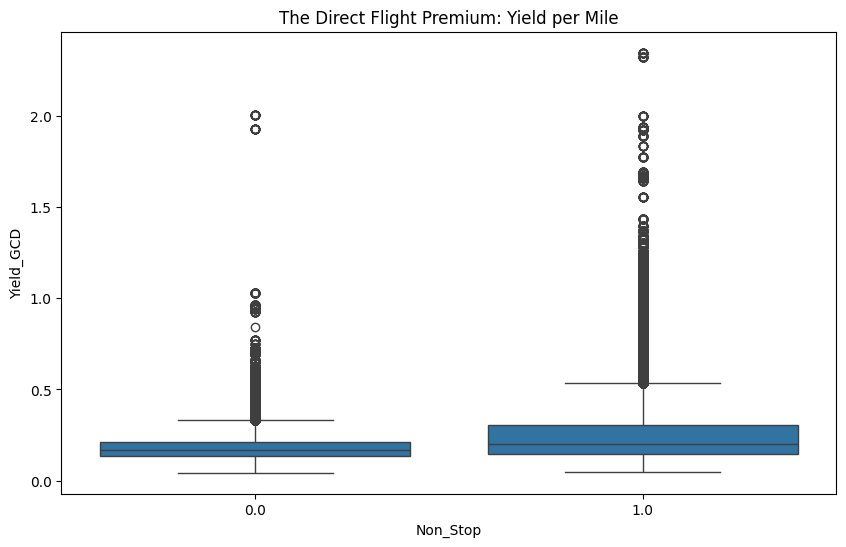

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x='Non_Stop', y='Yield_GCD', data=df)
plt.title('The Direct Flight Premium: Yield per Mile')
plt.show()

### Route Exploration

In [17]:
# Aggregate logic
route_summary = df.groupby('Route_ID').agg(
    total_pax=('Pax', 'sum'),
    avg_fare_weighted=('Average_Fare', lambda x: (x * df.loc[x.index, 'CarrierPax']).sum() / df.loc[x.index, 'CarrierPax'].sum()),
    mean_hhi=('Market_HHI', 'mean'),
    has_lcc=('LCC_Comp', 'max'),
    carrier_count=('Carrier', 'nunique')
).reset_index()

In [18]:
route_summary.head()

,Route_ID,total_pax,avg_fare_weighted,mean_hhi,has_lcc,carrier_count
0,0_20,1412160.0,204.960000,9993.20,0,1
1,100_12,1307665.0,284.700000,9825.28,1,1
2,100_139,3459092.0,143.333724,5932.56,1,2
3,100_152,18253260.0,148.306220,3071.63,1,4
4,100_159,7021342.0,165.963350,2505.98,1,4


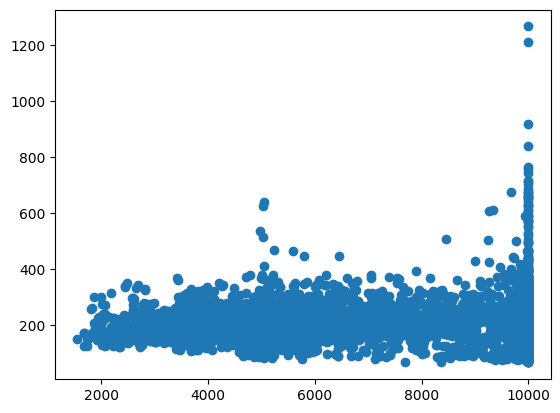

In [19]:
import matplotlib.pyplot as plt

plt.scatter(x=route_summary["mean_hhi"],y=route_summary["avg_fare_weighted"])
plt.show()

In [20]:
import plotly.express as px
px.scatter(x=route_summary["mean_hhi"],y=route_summary["avg_fare_weighted"])



In [ ]:
route_summary["Route_ID"][3590]

In [32]:
# 1. Create a set of all unique routes for lightning-fast lookup
unique_routes = set(df['Route_ID'].unique())

# 2. Generate the "Expected Return" ID for every row
# We just swap the Origin and Dest columns
df['Return_ID'] = df['DestCityMarketID'].astype(str) + '_' + df['OriginCityMarketID'].astype(str)

# 3. Check if the Return_ID exists in our master list of routes
df['is_bidirectional'] = df['Return_ID'].isin(unique_routes)

# Clean up
df.drop(columns=['Return_ID'], inplace=True)

In [30]:
import numpy as np

# Use numpy for speed: it's much faster than .apply(sorted) on large datasets
orig = df['OriginCityMarketID'].values
dest = df['DestCityMarketID'].values

# Create two arrays: one with the lower ID, one with the higher ID
mkt_min = np.minimum(orig, dest)
mkt_max = np.maximum(orig, dest)

# Combine them into a non-directional Market_ID
df['Market_ID'] = mkt_min.astype(str) + '_' + mkt_max.astype(str)

In [ ]:
import seaborn as sns
# Plot the price imbalance

bidirectional_df = df[df["is_bidirectional"]==1]

# 1. First, calculate the weighted average fare per Route_ID 
# This collapses multiple carriers into one directional route price
directional_summary = bidirectional_df.groupby(['Market_ID', 'Route_ID']).agg(
    route_avg_fare=('Average_Fare', lambda x: (x * bidirectional_df.loc[x.index, 'CarrierPax']).sum() / bidirectional_df.loc[x.index, 'CarrierPax'].sum())
).reset_index()

# 2. Now pivot. Since we grouped by Route_ID, we have one value per cell.
# If you still have duplicates (e.g. across time), use pivot_table with an aggfunc
imbalance_df = directional_summary.pivot(index='Market_ID', columns='Route_ID', values='route_avg_fare')

# 3. Rename columns to 'Direction_1' and 'Direction_2' for easy plotting
# Because every Market_ID has exactly 2 directions (since we filtered for bidirectional)
imbalance_clean = pd.DataFrame({
    'Fare_A': imbalance_df.apply(lambda x: x.dropna().iloc[0], axis=1),
    'Fare_B': imbalance_df.apply(lambda x: x.dropna().iloc[1], axis=1)
}).reset_index()

In [36]:
# 1. Create a unique key for each carrier in each market
df['Carrier_Market_ID'] = df['Market_ID'].astype(str) + "_" + df['Carrier'].astype(str)

# 2. Identify carriers that fly BOTH directions in a market
# We count unique Route_IDs (Directional) per Carrier_Market_ID
carrier_direction_counts = df.groupby('Carrier_Market_ID')['Route_ID'].nunique()
valid_carrier_markets = carrier_direction_counts[carrier_direction_counts == 2].index

# 3. Filter for these bidirectional carrier-markets
carrier_imbalance_df = df[df['Carrier_Market_ID'].isin(valid_carrier_markets)]

# Pivot to get Side A and Side B for each carrier
carrier_pivot = carrier_imbalance_df.pivot_table(
    index=['Market_ID', 'Carrier'], 
    columns='Route_ID', 
    values='Average_Fare'
).reset_index()

# Because Route_IDs are strings, we'll standardize the column names to Fare_1 and Fare_2
# This helper picks the first non-null fare and the second non-null fare
carrier_pivot['Fare_Low_ID'] = carrier_pivot.iloc[:, 2:].apply(lambda x: x.dropna().iloc[0], axis=1)
carrier_pivot['Fare_High_ID'] = carrier_pivot.iloc[:, 2:].apply(lambda x: x.dropna().iloc[1], axis=1)

# Calculate the Imbalance Ratio for each carrier
carrier_pivot['Imbalance_Ratio'] = carrier_pivot['Fare_Low_ID'] / carrier_pivot['Fare_High_ID']
# (We use abs(1 - ratio) to see the magnitude of the swing)
carrier_pivot['Imbalance_Magnitude'] = abs(carrier_pivot['Fare_Low_ID'] - carrier_pivot['Fare_High_ID'])

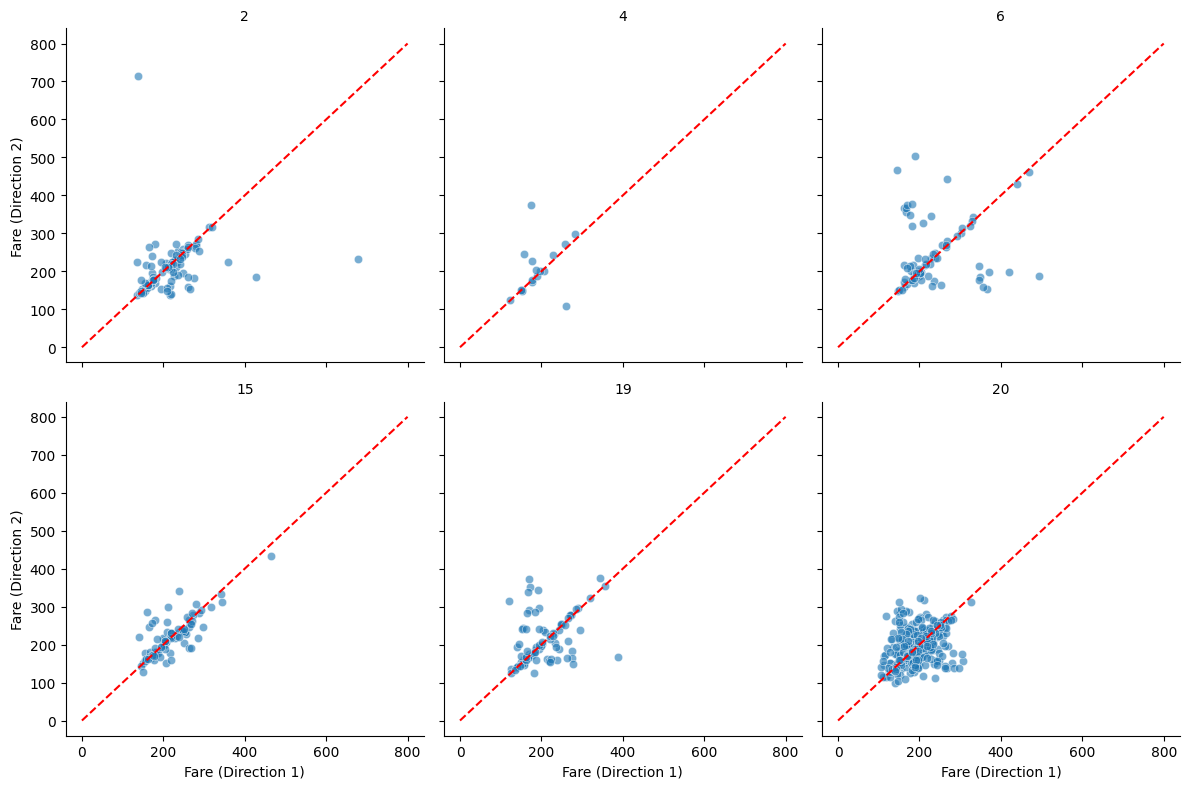

In [37]:
# Filter for the top 5-6 carriers to keep the plot clean
top_carriers = df['Carrier'].value_counts().nlargest(6).index
plot_data = carrier_pivot[carrier_pivot['Carrier'].isin(top_carriers)]

g = sns.FacetGrid(plot_data, col="Carrier", col_wrap=3, height=4)
g.map(sns.scatterplot, "Fare_Low_ID", "Fare_High_ID", alpha=0.6)

# Add parity lines to each subplot
for ax in g.axes.flat:
    ax.plot([0, 800], [0, 800], color='red', linestyle='--')

g.set_axis_labels("Fare (Direction 1)", "Fare (Direction 2)")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

# ML

In [21]:
# PCA
# UMAP

In [22]:
# ROUTE CLUSTERING